# 客服信件分析 Agent — ChatOllama + 結果分析

使用本地 **ChatOllama（qwen3.5:4b-q4_K_M）** 搭配 LangChain `create_agent`，  
對 `dataset_balanced.json` 的 **30 封**客服信件進行**雙維度自動分類**，結果輸出至 CSV。

---

## 📋 任務總覽

### 🎯 目標

自動分析電商客服信件，同時完成**兩種分類**：

| 維度 | 欄位 | 類別 |
|------|------|------|
| **類別分類** | `category` | `order_inquiry` / `shipping_issue` / `refund_request` / `complaint` / `general_question` |
| **情緒分類** | `sentiment` | `positive`（正面）/ `neutral`（中性）/ `negative`（負面）|

同時完成：`priority` 優先級判斷、`summary` 摘要、`aiSuggestedReply` AI 建議回覆、訂單狀態工具查詢。

---

### 🔄 完整任務流程

```
┌──────────────────────────────┐
│  dataset_balanced.json       │  30 封客服 email（主旨 + 內文 + 寄件人）
└───────────────┬──────────────┘
                │ 逐封讀入
                ▼
┌──────────────────────────────────────────────────────────────────┐
│                  LangChain create_agent（ReAct 架構）             │
│                                                                  │
│  [輸入] email 主旨 + 內容 + 寄件人                               │
│      │                                                           │
│      ▼                                                           │
│  [判斷] 信件中是否有訂單號？                                     │
│      ├── 有訂單號 ──▶ 呼叫工具 query_order_status(order_number)  │
│      │               └──▶ 查詢 order_data.json                   │
│      │               └──▶ 返回訂單狀態與配送資訊                 │
│      └── 無訂單號 ──▶ 跳過工具，直接分析                        │
│      │                                                           │
│      ▼                                                           │
│  [雙維度分類]                                                    │
│      ├── category：依主要訴求分為 5 類                           │
│      └── sentiment：依情緒分為正 / 中性 / 負                    │
│      │                                                           │
│      ▼                                                           │
│  [生成] summary（繁中摘要）+ aiSuggestedReply（建議回覆）        │
│                                                                  │
│  模型：qwen3.5:4b-q4_K_M（本地 Ollama，無需 API Key）           │
└───────────────────────────────┬──────────────────────────────────┘
                                │
                                ▼
              ┌─────────────────────────────┐
              │       output_v4.csv         │  30 列 × 9 欄位
              └─────────────────────────────┘
```

---

### 📂 輸入資料

| 檔案 | 說明 | 筆數 |
|------|------|------|
| `data/dataset_balanced.json` | 客服 email（主旨、內文、寄件人） | 30 封 |
| `data/order_data.json` | 訂單狀態資料庫（訂單號 → 狀態） | 39 筆 |

## 步驟 1：匯入套件 & 設定環境

**前提條件確認：**
1. Ollama 已啟動：執行 `ollama serve`
2. 模型已下載：執行 `ollama pull qwen3.5:4b-q4_K_M`

使用 `langchain_community.chat_models.ChatOllama` 連接本地 Ollama，**不需要任何 API Key**。

小提醒：requirements.txt 有更新套件內容，若無法執行請重新安裝套件

```bash
!pip install -r requirements.txt

In [1]:
import json
import csv
import re
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import JsonOutputParser
from langchain_ollama import ChatOllama

/home/vince-ylf/.conda/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vince-ylf/.conda/envs/NLP/lib/python3.12/site-packages/langgraph/checkpoint/base/__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 步驟 2：載入訂單資料 & 定義工具

**工具說明：**
`query_order_status` 是 Agent 唯一可用的工具。當 LLM 判斷信件中有訂單號時，
會自動呼叫此工具查詢 `order_data.json`，取得訂單狀態後再生成回覆。

```
LLM 判斷 → 有訂單號 → 呼叫 query_order_status("23891") → 取得 JSON → 更新 summary
                       └─ 查詢 order_data.json ──────────────────────────────────┘
```

In [2]:
with open("data/order_data.json", encoding="utf-8") as f:
    ORDER_DATA = json.load(f)

@tool
def query_order_status(order_number: str) -> str:
    """根據訂單編號查詢訂單狀態與配送資訊。order_number 為純數字字串，例如 '23891'。"""
    order_number = order_number.strip()
    if order_number in ORDER_DATA:
        return json.dumps(ORDER_DATA[order_number], ensure_ascii=False)
    return f"找不到訂單編號 {order_number}"


print(f"已載入 {len(ORDER_DATA)} 筆訂單資料")
print("工具：query_order_status（查詢 order_data.json）")

print("\n快速測試工具（訂單 23891）：")
print(query_order_status.invoke({"order_number": "23891"}))

已載入 39 筆訂單資料
工具：query_order_status（查詢 order_data.json）

快速測試工具（訂單 23891）：
{"status": "shipped", "shippingStatus": "in_transit", "estimatedDeliveryDate": "2026-05-05", "note": "包裹已出貨，目前配送中，客戶反映尚未收到"}


## 步驟 3：定義 SYSTEM_PROMPT & 建立 Agent

SYSTEM_PROMPT 是 Agent 的行為指南，本版本特別強調**雙維度分類規則**：

| 分類 | 規則 | 範例 |
|------|------|------|
| `category` | 依**主要訴求**判斷 | 詢問訂單 → `order_inquiry` |
| `sentiment` | 依**情緒語氣**判斷 | 強烈不滿 → `negative` |

**重要觀念**：category 和 sentiment 是**獨立的兩個維度**。
例如：客戶抱怨客服太慢但仍在詢問訂單狀態 → `category=order_inquiry, sentiment=negative`

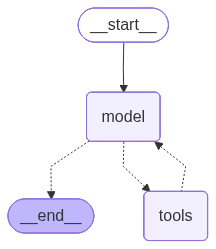

In [3]:
SYSTEM_PROMPT = """你是一位電商客服 AI 助理，負責分析並分類客服信件。
請依照以下規則處理每封信件，最後輸出 JSON 格式結果。

【工具使用規則】
如果信件中提到訂單編號（純數字），你必須呼叫 query_order_status 工具查詢，
並將查詢結果納入 summary 說明中。

【雙維度分類說明】

1. 類別分類（category）— 依照客戶的主要訴求：
   - order_inquiry：詢問訂單狀態、查詢出貨進度、修改訂單資訊等
   - shipping_issue：物流延遲、包裹未收到、配送異常等
   - refund_request：申請退貨、退款、換貨等
   - complaint：強烈投訴、要求補償、明確表達憤怒與不滿等
   - general_question：一般產品詢問、帳號問題、好評回饋、其他諮詢等

2. 情緒分類（sentiment）— 依照客戶表達的情緒語氣：
   - positive：滿意、感謝、讚美、正面評價等
   - neutral：純詢問、中性描述、無明顯情緒起伏等
   - negative：不滿、憤怒、失望、抱怨、擔憂等

【優先級判斷（priority）】
- high：緊急情況、強烈投訴、重複扣款、收到錯誤商品等
- medium：一般待處理問題（退換貨、物流異常、付款問題等）
- low：一般詢問、好評感謝、非緊急問題等

【輸出格式】
分析完成後，直接輸出以下 JSON，不含任何其他文字或 markdown：
{"emailFrom": "寄件人信箱", "category": "類別", "priority": "優先級", "sentiment": "情緒", "orderNumber": "訂單編號（無則空字串）", "orderStatus": "工具查詢狀態（無則空字串）", "shippingStatus": "配送狀態（無則空字串）", "summary": "繁體中文摘要，含訂單查詢結果", "aiSuggestedReply": "繁體中文建議回覆信件"}
"""

llm = ChatOllama(
    model="qwen3.5:4b-q4_K_M",
    temperature=0,
    num_ctx=4096,
    reasoning=False
)

agent = create_agent(
    model=llm,
    tools=[query_order_status],
    system_prompt=SYSTEM_PROMPT,
)

from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    print("圖片生成錯誤")
    pass

## 步驟 4：定義輔助函式

**`parse_json_response`**：處理 Qwen3 系列模型可能產生的輸出格式：
- 去除 `<think>...</think>` 思考標記（Qwen3 thinking mode）
- 去除 ` ```json...``` ` markdown 包裝
- 容錯解析純 JSON

In [4]:
def format_email_input(email: dict) -> str:
    return (
        f"主旨：{email['emailSubject']}\n"
        f"內容：{email['emailBody']}\n"
        f"寄件人：{email['emailFrom']}"
    )


_json_parser = JsonOutputParser()


def parse_json_response(content: str) -> dict:
    """去除 thinking tags → JsonOutputParser → 兜底擷取 { ... }"""
    content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()
    try:
        return _json_parser.parse(content)
    except Exception:
        pass
    s, e = content.find('{'), content.rfind('}')
    if s != -1 and e > s:
        return _json_parser.parse(content[s:e + 1])
    raise ValueError(f"無法解析 JSON\n{content[:400]}")


def analyze_email(email: dict, verbose: bool = False) -> dict:
    result = agent.invoke(
        {"messages": [HumanMessage(content=format_email_input(email))]}
    )
    last_content = result["messages"][-1].content

    if verbose:
        print(f"[{email['emailFrom']}]")
        for msg in result["messages"]:
            if msg.type == "ai" and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"  → 工具呼叫：{tc['name']}({tc['args']})")
            elif msg.type == "tool":
                print(f"  ← 工具回傳：{msg.content[:80]}...")
        print()

    return parse_json_response(last_content)

## 步驟 5：載入資料集 & 單筆測試

先測試前 3 筆，確認 Agent 正常運作：
- email 1（grace.ho）：有訂單號 88012 → 應呼叫工具，neutral
- email 2（sophia.wang）：好評信，無訂單號 → 直接分析，sentiment 應為 **positive**
- email 3（mark.tsai）：有刮痕退貨，語氣強烈 → 有訂單號，sentiment 應為 **negative**

In [5]:
with open("data/dataset_balanced.json", encoding="utf-8") as f:
    emails = json.load(f)

print(f"資料集：{len(emails)} 封 email（dataset_balanced.json）\n")

# 測試前 3 筆，verbose=True 顯示工具呼叫過程
for email in emails[:3]:
    result = analyze_email(email, verbose=True)
    sentiment_icon = {"positive": "😊", "neutral": "😐", "negative": "😞"}.get(result.get("sentiment", ""), "❓")
    print(f"  category  = {result.get('category')}")
    print(f"  sentiment = {result.get('sentiment')} {sentiment_icon}")
    print(f"  priority  = {result.get('priority')}")
    print(f"  order#    = {result.get('orderNumber') or '（無）'}")
    print("-" * 60)

資料集：30 封 email（dataset_balanced.json）

[grace.ho@example.com]
  → 工具呼叫：query_order_status({'order_number': '88012'})
  ← 工具回傳：{"status": "urgent", "shippingStatus": "ready_to_ship", "estimatedShipDate": "20...
  → 工具呼叫：query_order_status({'order_number': '88012'})
  ← 工具回傳：{"status": "urgent", "shippingStatus": "ready_to_ship", "estimatedShipDate": "20...

  category  = order_inquiry
  sentiment = neutral 😐
  priority  = high
  order#    = 88012
------------------------------------------------------------
[sophia.wang@example.com]
  → 工具呼叫：query_order_status({'order_number': '23891'})
  ← 工具回傳：{"status": "shipped", "shippingStatus": "in_transit", "estimatedDeliveryDate": "...

  category  = general_question
  sentiment = positive 😊
  priority  = low
  order#    = （無）
------------------------------------------------------------
[mark.tsai@example.com]
  → 工具呼叫：query_order_status({'order_number': '31684'})
  ← 工具回傳：{"status": "return_requested", "shippingStatus": "delivered", "estimatedD

## 步驟 6：批次處理全部 30 筆並寫入 CSV

批次處理過程中即時顯示每筆的 **category × sentiment** 結果，方便監控。

輸出至 `data/output_v4.csv`（UTF-8 BOM 格式，可直接用 Excel 開啟）。

> ⏱️ **時間估計**：qwen3.5:4b-q4_K_M（think=False）每封約 3–10 秒，30 封預計 **3–8 分鐘**。

In [10]:
import time

CSV_FIELDS = [
    "emailFrom", "category", "priority", "sentiment",
    "orderNumber", "orderStatus", "shippingStatus",
    "summary", "aiSuggestedReply",
]
OUTPUT_CSV = "data/output_v4.csv"

results = []
errors = []
start_time = time.time()

SENTIMENT_ICONS = {"positive": "😊", "neutral": "😐", "negative": "😞"}

for i, email in enumerate(emails):
    t0 = time.time()
    try:
        row = analyze_email(email)
        results.append(row)
        cat = row.get('category', '?')
        sent = row.get('sentiment', '?')
        icon = SENTIMENT_ICONS.get(sent, '❓')
        elapsed = time.time() - t0
        status = f"✓  {cat:<22} {icon} {sent:<8}  ({elapsed:.0f}s)"
    except Exception as e:
        errors.append({"index": i, "emailFrom": email["emailFrom"], "error": str(e)})
        status = f"✗  ERROR: {e}"

    print(f"[{i+1:02d}/{len(emails)}] {email['emailFrom']:<40} {status}")

# 寫入 CSV
with open(OUTPUT_CSV, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=CSV_FIELDS, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results)

total_time = time.time() - start_time
print(f"\n完成：{len(results)} 筆成功，{len(errors)} 筆失敗")
print(f"總耗時：{total_time/60:.1f} 分鐘（平均 {total_time/len(emails):.0f} 秒/封）")
print(f"輸出：{OUTPUT_CSV}")

if errors:
    print("\n失敗清單：")
    for e in errors:
        print(f"  [{e['index']}] {e['emailFrom']}: {e['error']}")

[01/30] grace.ho@example.com                     ✓  order_inquiry          😐 neutral   (2s)
[02/30] sophia.wang@example.com                  ✓  general_question       😊 positive  (1s)
[03/30] mark.tsai@example.com                    ✓  refund_request         😞 negative  (2s)
[04/30] vivian.lin@example.com                   ✓  order_inquiry          😐 neutral   (2s)
[05/30] raymond.wu@example.com                   ✓  general_question       😊 positive  (2s)
[06/30] nina.yeh@example.com                     ✓  shipping_issue         😞 negative  (2s)
[07/30] andy.chen@example.com                    ✓  refund_request         😐 neutral   (2s)
[08/30] joanne.chou@example.com                  ✓  general_question       😊 positive  (1s)
[09/30] flora.wu@example.com                     ✓  shipping_issue         😞 negative  (2s)
[10/30] emily.huang@example.com                  ✓  order_inquiry          😐 neutral   (2s)
[11/30] gift.buyer@example.com                   ✓  general_question       😊 pos

## 步驟 7：雙維度分類結果視覺化

批次完成後，以 matplotlib 繪製 4 張圖表：

| 圖表 | 類型 | 說明 |
|------|------|------|
| 類別分布 | 橫向長條圖 | 各 category 筆數與佔比 |
| 情緒分布 | 圓餅圖 | positive / neutral / negative 比例 |
| 優先級分布 | 直向長條圖 | high / medium / low 筆數 |
| 情緒 × 類別 | 堆疊長條圖 | 不同情緒在各類別的分布 |

> 圖表同步儲存為 `data/analysis_v4.png`

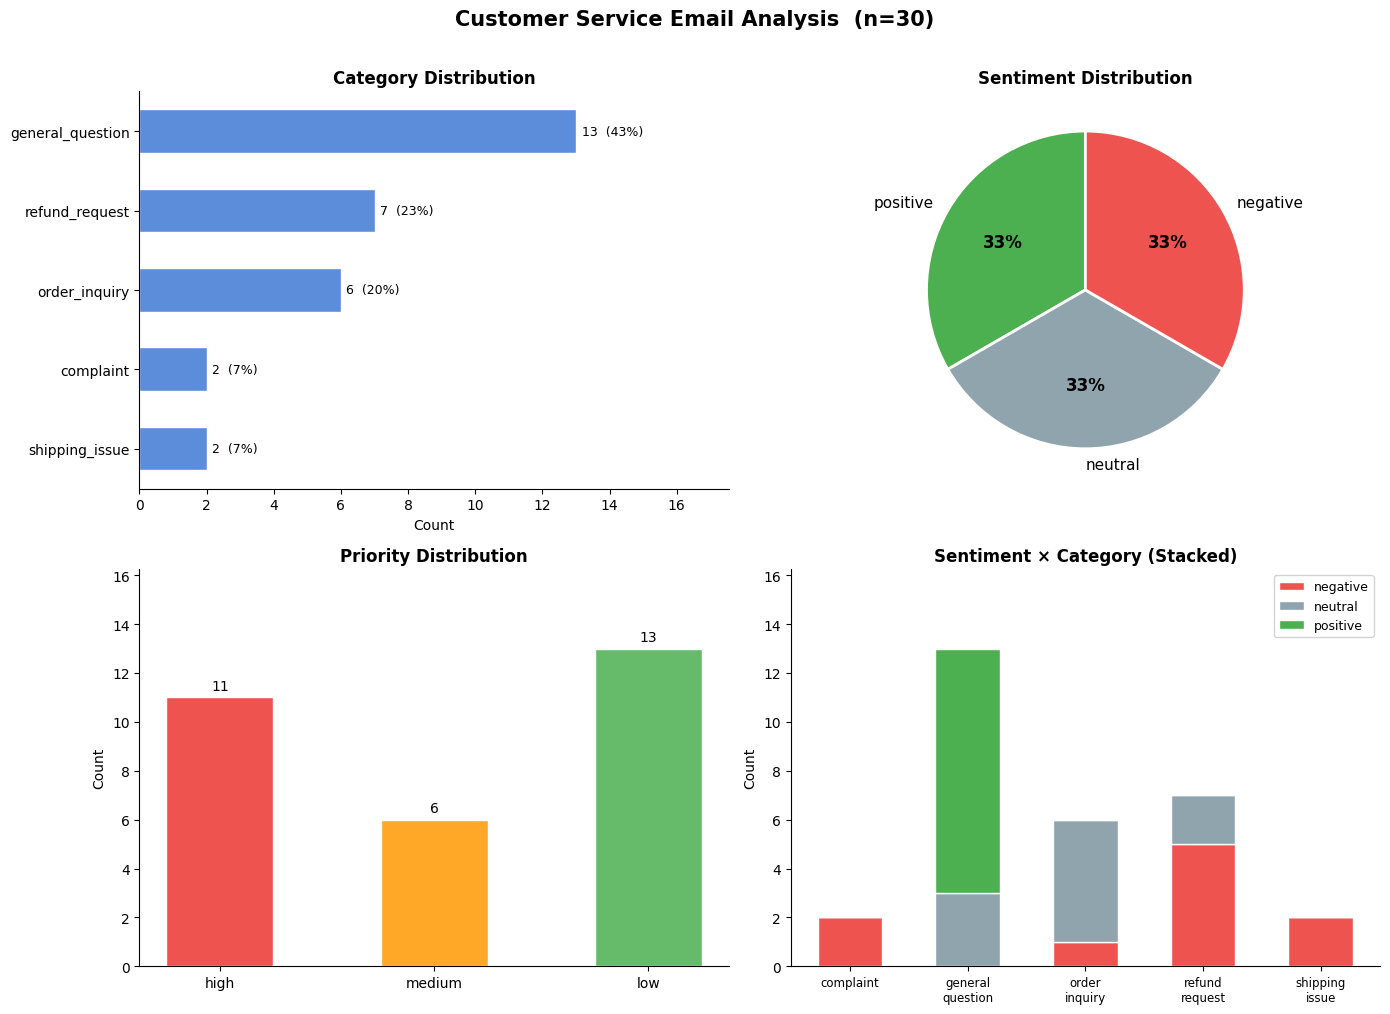

圖表已儲存：data/analysis_v4.png
情緒分布：positive=10  neutral=10  negative=10


In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter

# 嘗試設定支援中文的字型，失敗則使用預設字型
for font in ["Noto Sans CJK TC", "Noto Sans CJK SC", "SimHei", "Microsoft JhengHei"]:
    if any(font.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

# ── 載入 CSV 結果 ─────────────────────────────────────────
with open(OUTPUT_CSV, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

n = len(rows)
categories = Counter(r["category"] for r in rows)
sentiments = Counter(r["sentiment"] for r in rows)
priorities = Counter(r["priority"] for r in rows)

SENT_COLORS = {"positive": "#4CAF50", "neutral": "#90A4AE", "negative": "#EF5350"}
PRI_COLORS  = {"high": "#EF5350", "medium": "#FFA726", "low": "#66BB6A"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Customer Service Email Analysis  (n={n})",
             fontsize=15, fontweight="bold", y=1.01)

# ── 圖 1：類別分布（橫向長條）────────────────────────────
ax1 = axes[0, 0]
cats = sorted(categories, key=lambda c: categories[c])
vals = [categories[c] for c in cats]
bars1 = ax1.barh(cats, vals, color="#5C8DDB", edgecolor="white", height=0.55)
ax1.set_xlabel("Count")
ax1.set_title("Category Distribution", fontweight="bold")
ax1.bar_label(bars1, labels=[f"{v}  ({v/n*100:.0f}%)" for v in vals], padding=4, fontsize=9)
ax1.set_xlim(0, max(vals) * 1.35)
ax1.spines[["top", "right"]].set_visible(False)

# ── 圖 2：情緒分布（圓餅圖）──────────────────────────────
ax2 = axes[0, 1]
sent_order  = ["positive", "neutral", "negative"]
sent_vals   = [sentiments.get(s, 0) for s in sent_order]
sent_colors = [SENT_COLORS[s] for s in sent_order]
wedges, texts, autotexts = ax2.pie(
    sent_vals,
    labels=sent_order,
    colors=sent_colors,
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
ax2.set_title("Sentiment Distribution", fontweight="bold")

# ── 圖 3：優先級分布（直向長條）──────────────────────────
ax3 = axes[1, 0]
pri_order  = ["high", "medium", "low"]
pri_vals   = [priorities.get(p, 0) for p in pri_order]
pri_colors = [PRI_COLORS[p] for p in pri_order]
bars3 = ax3.bar(pri_order, pri_vals, color=pri_colors, edgecolor="white", width=0.5)
ax3.set_ylabel("Count")
ax3.set_title("Priority Distribution", fontweight="bold")
ax3.bar_label(bars3, fmt="%d", padding=3)
ax3.set_ylim(0, max(pri_vals) * 1.25)
ax3.spines[["top", "right"]].set_visible(False)

# ── 圖 4：情緒 × 類別堆疊長條 ────────────────────────────
ax4 = axes[1, 1]
all_cats   = sorted(set(r["category"] for r in rows))
x          = range(len(all_cats))
bottom     = [0] * len(all_cats)

for sent in ["negative", "neutral", "positive"]:
    heights = [
        sum(1 for r in rows if r["sentiment"] == sent and r["category"] == cat)
        for cat in all_cats
    ]
    ax4.bar(x, heights, bottom=bottom, color=SENT_COLORS[sent],
            edgecolor="white", label=sent, width=0.55)
    bottom = [b + h for b, h in zip(bottom, heights)]

ax4.set_xticks(list(x))
ax4.set_xticklabels(
    [c.replace("_", "\n") for c in all_cats],
    fontsize=8.5, ha="center"
)
ax4.set_ylabel("Count")
ax4.set_title("Sentiment × Category (Stacked)", fontweight="bold")
ax4.legend(loc="upper right", framealpha=0.85, fontsize=9)
ax4.set_ylim(0, max(bottom) * 1.25)
ax4.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("data/analysis_v4.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"圖表已儲存：data/analysis_v4.png")
print(f"情緒分布：positive={sentiments.get('positive',0)}  "
      f"neutral={sentiments.get('neutral',0)}  "
      f"negative={sentiments.get('negative',0)}")

## 步驟 8：Langfuse 追蹤批次分析

批次處理 30 封 email 時，若不加追蹤，發生問題時很難診斷：
- 哪封 email 的 LLM 判斷異常？
- 哪些信件觸發了 `query_order_status` 工具？
- 整批的延遲分佈如何？

**Langfuse 追蹤策略：**
```
整批執行（30 封 email）
    └── 共用同一個 session_id（方便 Dashboard 彙總整批）
          ├── email 1 → 獨立 Trace（含工具呼叫 Span）
          ├── email 2 → 獨立 Trace
          └── email 30 → 獨立 Trace
```

**整合方式**：不修改現有 `analyze_email()`，新增 `analyze_email_with_tracing()` 函式，
在 `agent.invoke()` 的 `config` 中加入 `callbacks` 與 `metadata` 參數。

```python
# 原本
result = agent.invoke({"messages": [HumanMessage(content=human_msg)]})

# 加入追蹤後
result = agent.invoke(
    {"messages": [HumanMessage(content=human_msg)]},
    config={
        "callbacks": [langfuse_handler],          # ← Langfuse 攔截所有事件
        "metadata": {
            "langfuse_session_id": session_id,    # ← 整批共用
            "email_from": email["emailFrom"],     # ← 個別 email 資訊
        },
    },
)
```

> **安裝**：若尚未安裝，先執行 `pip install langfuse`  
> **帳號地區**：US 用 `https://us.cloud.langfuse.com`；EU 用 `https://cloud.langfuse.com`

### 設定 Langfuse API Keys

前往 [Langfuse Dashboard](https://cloud.langfuse.com) → **Settings → API Keys** 取得金鑰。

In [ ]:
# 若尚未安裝：!pip install langfuse
import os
import getpass
from langfuse import Langfuse

os.environ["LANGFUSE_PUBLIC_KEY"] = getpass.getpass("請輸入 Langfuse Public Key: ")
os.environ["LANGFUSE_SECRET_KEY"] = getpass.getpass("請輸入 Langfuse Secret Key: ")
os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com"  # 視帳號地區調整

lf = Langfuse(
    public_key=os.environ["LANGFUSE_PUBLIC_KEY"],
    secret_key=os.environ["LANGFUSE_SECRET_KEY"],
    host=os.environ["LANGFUSE_HOST"],
)
print("Langfuse 連線狀態:", lf.auth_check())

In [ ]:
from uuid import uuid4
from langfuse.langchain import CallbackHandler


def analyze_email_with_tracing(
    email: dict,
    session_id: str,
    verbose: bool = False,
) -> dict:
    """帶 Langfuse 追蹤的 email 分析，每封 email 產生獨立 Trace"""
    trace_id = uuid4().hex
    invoke_config = {
        "callbacks": [CallbackHandler(trace_context={"trace_id": trace_id})],
        "metadata": {
            "langfuse_session_id": session_id,
            "langfuse_user_id": "classroom-demo",
            "email_from": email["emailFrom"],
        },
    }

    result = agent.invoke(
        {"messages": [HumanMessage(content=format_email_input(email))]},
        config=invoke_config,
    )
    last_content = result["messages"][-1].content

    if verbose:
        print(f"[{email['emailFrom']}]")
        for msg in result["messages"]:
            if msg.type == "ai" and msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"  → 工具呼叫：{tc['name']}({tc['args']})")
            elif msg.type == "tool":
                print(f"  ← 工具回傳：{msg.content[:80]}...")
        print()

    parsed = parse_json_response(last_content)
    lf.flush()
    parsed["_trace_url"] = lf.get_trace_url(trace_id=trace_id)
    return parsed


print("analyze_email_with_tracing 函式定義完成")

In [ ]:
BATCH_SESSION_ID = f"cs-batch-{uuid4().hex[:8]}"
print(f"本批次 Session ID：{BATCH_SESSION_ID}\n")

for email in emails[:3]:
    result = analyze_email_with_tracing(email, session_id=BATCH_SESSION_ID, verbose=True)
    print(f"  category={result.get('category'):<22} "
          f"sentiment={result.get('sentiment'):<10} "
          f"trace={result.get('_trace_url')}")
    print("-" * 80)

In [ ]:
CSV_FIELDS_TRACED = CSV_FIELDS + ["trace_url"]
OUTPUT_CSV_TRACED = "data/output_v4_traced.csv"

results_traced = []
errors_traced = []

for i, email in enumerate(emails):
    try:
        row = analyze_email_with_tracing(email, session_id=BATCH_SESSION_ID)
        row["trace_url"] = row.pop("_trace_url", "")
        results_traced.append(row)
        cat = row.get('category', '?')
        sent = row.get('sentiment', '?')
        icon = SENTIMENT_ICONS.get(sent, '❓')
        status = f"✓  {cat:<22} {icon} {sent:<8}"
    except Exception as e:
        errors_traced.append({"index": i, "emailFrom": email["emailFrom"], "error": str(e)})
        status = f"✗  ERROR: {e}"

    print(f"[{i+1:02d}/{len(emails)}] {email['emailFrom']:<40} {status}")

with open(OUTPUT_CSV_TRACED, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=CSV_FIELDS_TRACED, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results_traced)

print(f"\n完成：{len(results_traced)} 筆成功，{len(errors_traced)} 筆失敗")
print(f"輸出：{OUTPUT_CSV_TRACED}（含 trace_url 欄）")
print(f"\n前往 Langfuse Dashboard → Sessions → {BATCH_SESSION_ID}")

## 步驟 9：Langfuse Prompt 管理

現有的 `SYSTEM_PROMPT` 硬編碼在程式碼裡，**每次調整分類規則都需要改程式碼**。

Langfuse Prompt 管理讓你把 `SYSTEM_PROMPT` 集中託管：
- 修改提示詞不需動程式碼，改完立即生效
- 自動保留所有歷史版本，可隨時 rollback
- Trace 可記錄「此次執行用的是哪個版本」，方便評估改版效果

### 在 Dashboard 建立 Prompt（手動操作）

1. 登入 [Langfuse Dashboard](https://cloud.langfuse.com)
2. 左側選單 **Prompts** → 右上角 **+ Create**
3. 填寫：
   - **Name**：`customer-service-agent`
   - **Type**：`Text`
   - **Prompt**：貼上 `SYSTEM_PROMPT` 的內容
```
你是一位電商客服 AI 助理，負責分析並分類客服信件。
請依照以下規則處理每封信件，最後輸出 JSON 格式結果。

【工具使用規則】
如果信件中提到訂單編號（純數字），你必須呼叫 query_order_status 工具查詢，
並將查詢結果納入 summary 說明中。

【雙維度分類說明】

1. 類別分類（category）— 依照客戶的主要訴求：
   - order_inquiry：詢問訂單狀態、查詢出貨進度、修改訂單資訊等
   - shipping_issue：物流延遲、包裹未收到、配送異常等
   - refund_request：申請退貨、退款、換貨等
   - complaint：強烈投訴、要求補償、明確表達憤怒與不滿等
   - general_question：一般產品詢問、帳號問題、好評回饋、其他諮詢等

2. 情緒分類（sentiment）— 依照客戶表達的情緒語氣：
   - positive：滿意、感謝、讚美、正面評價等
   - neutral：純詢問、中性描述、無明顯情緒起伏等
   - negative：不滿、憤怒、失望、抱怨、擔憂等

【優先級判斷（priority）】
- high：緊急情況、強烈投訴、重複扣款、收到錯誤商品等
- medium：一般待處理問題（退換貨、物流異常、付款問題等）
- low：一般詢問、好評感謝、非緊急問題等

【輸出格式】
分析完成後，直接輸出以下 JSON，不含任何其他文字或 markdown：
{"emailFrom": "寄件人信箱", "category": "類別", "priority": "優先級", "sentiment": "情緒", "orderNumber": "訂單編號（無則空字串）", "orderStatus": "工具查詢狀態（無則空字串）", "shippingStatus": "配送狀態（無則空字串）", "summary": "繁體中文摘要，含訂單查詢結果", "aiSuggestedReply": "繁體中文建議回覆信件"}
```
4. 點 **Save** 建立 Version 1
5. 點版本旁的 **Add label** → 輸入 `production`

完成後執行下方程式碼。

In [ ]:
# 拉取 Langfuse 上的 customer-service-agent prompt
prompt_obj = lf.get_prompt("customer-service-agent")

print(f"Prompt 名稱：{prompt_obj.name}")
print(f"版本：v{prompt_obj.version}")
print(f"Labels：{prompt_obj.labels}")
print(f"\n--- 內容（前 200 字）---")
print(prompt_obj.prompt[:200])

In [ ]:
# 用 Langfuse 託管的 prompt 重建 Agent
managed_prompt = lf.get_prompt("customer-service-agent")

agent_managed = create_agent(
    model=llm,
    tools=[query_order_status],
    system_prompt=managed_prompt.prompt,
)
print(f"使用 Prompt：{managed_prompt.name} v{managed_prompt.version}")
print("agent_managed 建立完成")


def analyze_email_managed(email: dict, session_id: str) -> dict:
    """使用 Langfuse 託管 prompt 的 email 分析，記錄 prompt 版本至 Trace"""
    p = lf.get_prompt("customer-service-agent")
    trace_id = uuid4().hex
    handler = CallbackHandler(trace_context={"trace_id": trace_id})

    result = agent_managed.invoke(
        {"messages": [HumanMessage(content=format_email_input(email))]},
        config={
            "callbacks": [handler],
            "metadata": {
                "langfuse_session_id": session_id,
                "langfuse_user_id": "classroom-demo",
                "prompt_name": p.name,
                "prompt_version": str(p.version),
            },
        },
    )
    parsed = parse_json_response(result["messages"][-1].content)
    lf.flush()
    parsed["_trace_url"] = lf.get_trace_url(trace_id=trace_id)
    return parsed


# 驗證：前 2 封 email
MANAGED_SESSION_ID = f"cs-managed-{uuid4().hex[:8]}"
print(f"\nSession ID：{MANAGED_SESSION_ID}\n")

for email in emails[:2]:
    r = analyze_email_managed(email, session_id=MANAGED_SESSION_ID)
    print(f"{email['emailFrom']:<35}  category={r.get('category'):<22}  "
          f"prompt_v={managed_prompt.version}")
    print(f"  Trace URL: {r.get('_trace_url')}")
    print()

In [ ]:
BATCH_MANAGED_CSV = "data/output_v4_managed.csv"

results_managed = []
errors_managed = []

for i, email in enumerate(emails):
    try:
        row = analyze_email_managed(email, session_id=MANAGED_SESSION_ID)
        row["trace_url"] = row.pop("_trace_url", "")
        results_managed.append(row)
        status = f"✓  {row.get('category', '?'):<22} [{row.get('sentiment', '?')}]"
    except Exception as e:
        errors_managed.append({"index": i, "emailFrom": email["emailFrom"], "error": str(e)})
        status = f"✗  ERROR: {e}"

    print(f"[{i+1:02d}/{len(emails)}] {email['emailFrom']:<40} {status}")

with open(BATCH_MANAGED_CSV, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=CSV_FIELDS_TRACED, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(results_managed)

print(f"\n完成：{len(results_managed)} 筆成功，{len(errors_managed)} 筆失敗")
print(f"輸出：{BATCH_MANAGED_CSV}（含 trace_url 欄）")
print(f"\n前往 Langfuse Dashboard → Sessions → {MANAGED_SESSION_ID}")

### 版本控制與 Rollback

#### 發布 v2（Dashboard 操作）
1. **Prompts → customer-service-agent** → 點 **Edit**
2. 修改分類規則（例如新增情緒細分標準、調整 priority 邏輯）
3. **Save** → 自動建立 v2
4. 將 `production` label 移至 v2

#### Rollback（程式碼方式）
```python
# 取回 v1 內容，建立新版本並標為 production
old = lf.get_prompt("customer-service-agent", version=1)
lf.create_prompt(name="customer-service-agent", prompt=old.prompt, labels=["production"])
```

#### A/B 比較不同版本效果
在 Dashboard → **Traces** 頁面，用 `metadata.prompt_version` 篩選：
- `prompt_version = 1` → 看舊版分類結果
- `prompt_version = 2` → 看新版分類結果

---

### Langfuse 整合總結

| 功能 | 方法 | 說明 |
|------|------|------|
| 每封 email 追蹤 | `CallbackHandler(trace_context={"trace_id": ...})` | 獨立 Trace，可看工具呼叫細節 |
| 批次 Session 管理 | `metadata["langfuse_session_id"]` | 58 封共用 session，Dashboard 可彙總 |
| 拉取 Prompt | `lf.get_prompt("customer-service-agent")` | 預設取 `production` label 版本 |
| 使用託管 Prompt | `create_agent(..., system_prompt=prompt_obj.prompt)` | 修改 prompt 不用改程式碼 |
| 記錄 Prompt 版本 | `metadata["prompt_version"] = str(p.version)` | 必須是字串，方便 Dashboard 篩選 |
| Rollback | `lf.create_prompt(..., labels=["production"])` | 以舊內容建新版，重設 production |